In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [18]:
df = pd.read_csv("house_price_dataset.csv")

In [19]:
df.shape

(25, 6)

In [20]:
list(df.columns)

['area_sqft',
 'bedrooms',
 'bathrooms',
 'age_years',
 'distance_km',
 'price_lakh']

In [21]:
df.head()

,area_sqft,bedrooms,bathrooms,age_years,distance_km,price_lakh
0,850,2,1,10,5.2,45
1,1200,3,2,5,3.1,72
2,950,2,1,15,7.8,38
3,1500,3,2,2,2.5,95
4,600,1,1,20,9.0,25


In [22]:
df.describe()

,area_sqft,bedrooms,bathrooms,age_years,distance_km,price_lakh
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,1298.800000,2.880000,1.960000,8.600000,4.664000,77.120000
std,506.329274,1.129897,0.934523,6.922187,2.824134,42.680323
min,550.000000,1.000000,1.000000,1.000000,1.200000,18.000000
25%,900.000000,2.000000,1.000000,3.000000,2.500000,40.000000
50%,1250.000000,3.000000,2.000000,6.000000,3.700000,75.000000
75%,1650.000000,4.000000,2.000000,12.000000,6.300000,105.000000
max,2400.000000,5.000000,4.000000,25.000000,11.000000,168.000000


In [23]:
print(df.describe().round(2).to_string()) 

       area_sqft  bedrooms  bathrooms  age_years  distance_km  price_lakh
count      25.00     25.00      25.00      25.00        25.00       25.00
mean     1298.80      2.88       1.96       8.60         4.66       77.12
std       506.33      1.13       0.93       6.92         2.82       42.68
min       550.00      1.00       1.00       1.00         1.20       18.00
25%       900.00      2.00       1.00       3.00         2.50       40.00
50%      1250.00      3.00       2.00       6.00         3.70       75.00
75%      1650.00      4.00       2.00      12.00         6.30      105.00
max      2400.00      5.00       4.00      25.00        11.00      168.00


In [24]:
features = ['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'distance_km']
target   = 'price_lakh'

In [25]:
for f in features:
    r = df[f].corr(df[target])
    bar = "█" * int(abs(r) * 20)
    direction = "+" if r > 0 else "-"
    print(f"  {f:<15} {direction}{bar:<20} {r:.4f}")
 

  area_sqft       +███████████████████  0.9948
  bedrooms        +███████████████████  0.9602
  bathrooms       +███████████████████  0.9508
  age_years       -█████████████████    -0.8666
  distance_km     -██████████████████   -0.9042


Text(0.5, 1.01, 'EDA — Feature vs Price Scatter Plots')

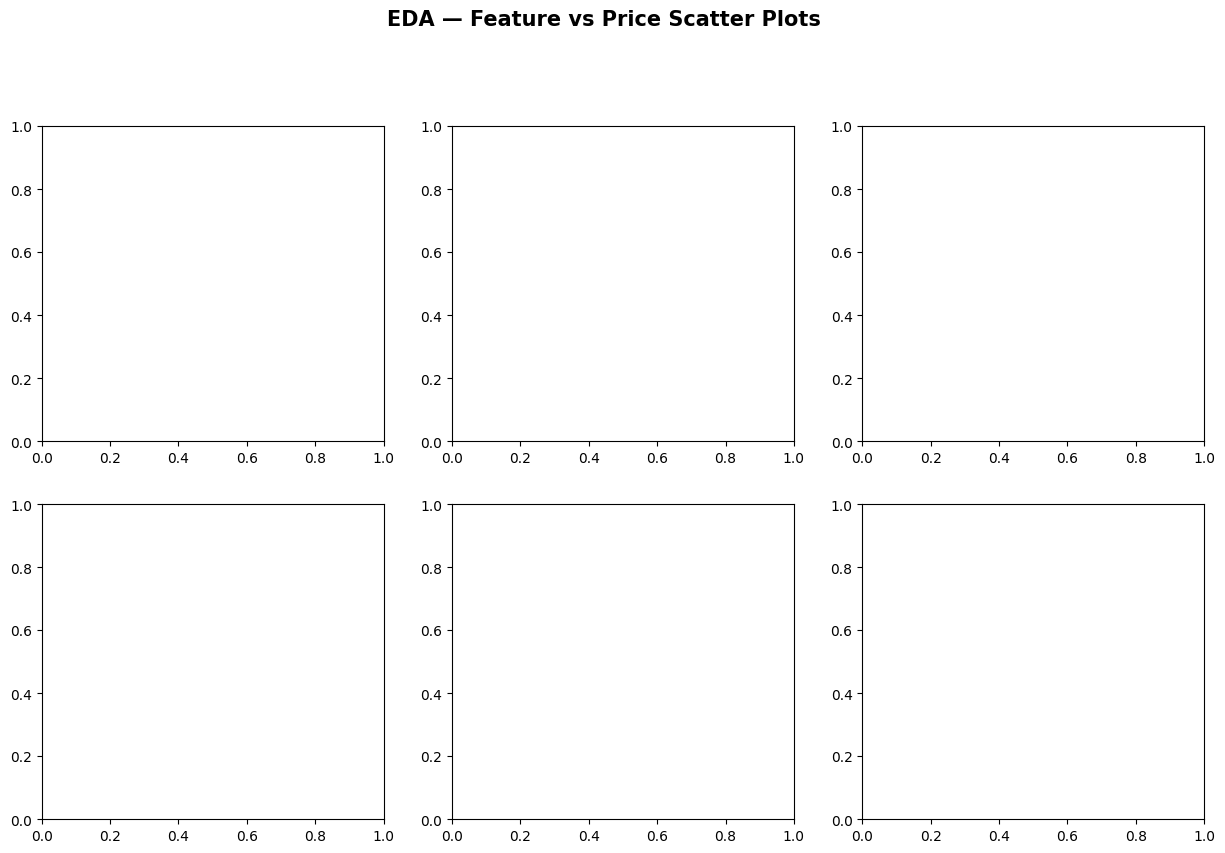

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("EDA — Feature vs Price Scatter Plots", fontsize=15, fontweight='bold', y=1.01)

In [27]:
for i, feat in enumerate(features):
    ax = axes[i // 3][i % 3]
    ax.scatter(df[feat], df[target], color='#534AB7', alpha=0.7, edgecolors='white', s=70)

In [28]:
m, b = np.polyfit(df[feat], df[target], 1)
x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
ax.plot(x_line, m * x_line + b, color='#E24B4A', linewidth=1.8, linestyle='--')
r = df[feat].corr(df[target])
ax.set_title(f"{feat}\n(r = {r:.3f})", fontsize=11, fontweight='bold')
ax.set_xlabel(feat, fontsize=9)
ax.set_ylabel("price_lakh", fontsize=9)
ax.grid(True, alpha=0.3)
ax.spines[['top','right']].set_visible(False)

In [29]:
ax = axes[1][2]
corrs = [df[f].corr(df[target]) for f in features]
colors = ['#1D9E75' if c > 0 else '#E24B4A' for c in corrs]
bars = ax.barh(features, corrs, color=colors, edgecolor='white', height=0.55)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title("Correlation with Price", fontsize=11, fontweight='bold')
ax.set_xlabel("Pearson r", fontsize=9)

Text(0.5, 4.444444444444452, 'Pearson r')

In [30]:
for bar, v in zip(bars, corrs):
    ax.text(v + (0.02 if v > 0 else -0.02), bar.get_y() + bar.get_height()/2,
            f"{v:.2f}", va='center', ha='left' if v > 0 else 'right', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')
ax.spines[['top','right']].set_visible(False)
 

In [31]:
plt.tight_layout()
plt.show()
plt.savefig("eda_scatter_plots.png", dpi=300, bbox_inches='tight')  
plt.close()

<Figure size 640x480 with 0 Axes>

In [32]:
X = df[features].values
y = df[target].values
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [33]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
 

In [34]:
for f, m in zip(features, scaler.mean_):
    print(f"{f}: Mean = {m:.2f}")

area_sqft: Mean = 1193.50
bedrooms: Mean = 2.65
bathrooms: Mean = 1.80
age_years: Mean = 9.65
distance_km: Mean = 5.16


In [35]:
for f, s in zip(features, scaler.scale_):
    print(f"{f}: Scale = {s:.2f}")

area_sqft: Scale = 432.50
bedrooms: Scale = 1.01
bathrooms: Scale = 0.81
age_years: Scale = 7.07
distance_km: Scale = 2.81


In [36]:
print("\nFirst training row (raw)  :", X_train[0])
print("First training row (scaled):", np.round(X_train_sc[0], 4))


First training row (raw)  : [1350.     3.     2.     6.     3.7]
First training row (scaled): [ 0.3619  0.3453  0.2462 -0.5166 -0.5176]


In [37]:
model = LinearRegression()
model.fit(X_train_sc, y_train)

LinearRegression()

In [38]:
for feat, coef in zip(features, model.coef_):
    direction = "↑ price" if coef > 0 else "↓ price"
    print(f"  {feat:<15}: {coef:+.4f}  ({direction})")

  area_sqft      : +28.7412  (↑ price)
  bedrooms       : -1.6177  (↓ price)
  bathrooms      : +5.8353  (↑ price)
  age_years      : -6.0868  (↓ price)
  distance_km    : +1.2960  (↑ price)


In [39]:
eq = f"{model.intercept_:.2f}"
for feat, coef in zip(features, model.coef_):
    eq += f" + ({coef:.4f} × {feat}_scaled)"
print(" ", eq)

  68.15 + (28.7412 × area_sqft_scaled) + (-1.6177 × bedrooms_scaled) + (5.8353 × bathrooms_scaled) + (-6.0868 × age_years_scaled) + (1.2960 × distance_km_scaled)


In [40]:
y_pred_train = model.predict(X_train_sc)
y_pred_test  = model.predict(X_test_sc)

r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test, y_pred_test)
mae_test  = mean_absolute_error(y_test, y_pred_test)
mse_test  = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)

In [41]:
print(f"\n{'Metric':<25} {'Train':>10} {'Test':>10}")
print("-" * 45)
print(f"{'R² Score':<25} {r2_train:>10.4f} {r2_test:>10.4f}")
print(f"{'MAE (lakh)':<25} {'—':>10} {mae_test:>10.4f}")
print(f"{'MSE (lakh²)':<25} {'—':>10} {mse_test:>10.4f}")
print(f"{'RMSE (lakh)':<25} {'—':>10} {rmse_test:>10.4f}")
 


Metric                         Train       Test
---------------------------------------------
R² Score                      0.9908     0.9941
MAE (lakh)                         —     2.8163
MSE (lakh²)                        —     9.6512
RMSE (lakh)                        —     3.1066


In [42]:
print(f"  {'Sample':<8} {'Actual':>10} {'Predicted':>10} {'Residual':>10} {'Abs Error':>10}")
residuals = y_test - y_pred_test
for i, (act, pred, res) in enumerate(zip(y_test, y_pred_test, residuals)):
    print(f"  {i+1:<8} {act:>10.1f} {pred:>10.2f} {res:>10.2f} {abs(res):>10.2f}")

  Sample       Actual  Predicted   Residual  Abs Error
  1             135.0     132.48       2.52       2.52
  2             112.0     112.64      -0.64       0.64
  3              45.0      40.33       4.67       4.67
  4             168.0     165.15       2.85       2.85
  5             105.0     101.60       3.40       3.40


In [43]:
if r2_test >= 0.9:
    print("  Excellent fit — model explains >90% of price variance")
elif r2_test >= 0.75:
    print("  Good fit — model explains >75% of price variance")
else:
    print("  Moderate fit — consider adding more features")

  Excellent fit — model explains >90% of price variance


In [44]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Linear Regression — Model Evaluation", fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

<Figure size 1600x1200 with 0 Axes>

In [45]:
#Regression line (area_sqft)
ax1 = fig.add_subplot(gs[0, 0])
area_idx = 0
area_raw_train = X_train[:, area_idx]
area_raw_test  = X_test[:, area_idx]
m_area = np.polyfit(area_raw_train, y_train, 1)
x_line = np.linspace(df['area_sqft'].min(), df['area_sqft'].max(), 100)
ax1.scatter(area_raw_train, y_train, color='#534AB7', alpha=0.7, s=60, label='Train', zorder=3)
ax1.scatter(area_raw_test, y_test, color='#E24B4A', alpha=0.9, s=80, marker='*', label='Test', zorder=4)
ax1.plot(x_line, m_area[0]*x_line + m_area[1], color='#1D9E75', linewidth=2, label='Regression line')
ax1.set_title("Regression Line\n(area_sqft)", fontweight='bold')
ax1.set_xlabel("area_sqft"); ax1.set_ylabel("price_lakh")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

In [46]:
#Actual vs Predicted (test)
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_test, y_pred_test, color='#534AB7', s=100, edgecolors='white', zorder=3)
lims = [min(y_test.min(), y_pred_test.min())-5, max(y_test.max(), y_pred_test.max())+5]
ax2.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax2.set_xlim(lims); ax2.set_ylim(lims)
ax2.set_title("Actual vs Predicted\n(Test Set)", fontweight='bold')
ax2.set_xlabel("Actual Price (lakh)"); ax2.set_ylabel("Predicted Price (lakh)")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
ax2.spines[['top','right']].set_visible(False)
 

In [47]:
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(y_pred_test, residuals, color='#534AB7', s=100, edgecolors='white', zorder=3)
ax3.axhline(0, color='#E24B4A', linestyle='--', linewidth=1.5)
ax3.set_title("Residuals vs Predicted\n(Test Set)", fontweight='bold')
ax3.set_xlabel("Predicted Price"); ax3.set_ylabel("Residual (Actual − Predicted)")
ax3.grid(True, alpha=0.3)
ax3.spines[['top','right']].set_visible(False)

In [48]:
#Actual vs Predicted bar chart
ax4 = fig.add_subplot(gs[1, 0])
x_pos = np.arange(len(y_test))
width = 0.35
ax4.bar(x_pos - width/2, y_test, width, label='Actual', color='#534AB7', alpha=0.8)
ax4.bar(x_pos + width/2, y_pred_test, width, label='Predicted', color='#1D9E75', alpha=0.8)
ax4.set_title("Actual vs Predicted\n(Bar Chart)", fontweight='bold')
ax4.set_xlabel("Test Sample"); ax4.set_ylabel("Price (lakh)")
ax4.set_xticks(x_pos); ax4.set_xticklabels([f"#{i+1}" for i in range(len(y_test))])
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3, axis='y')
ax4.spines[['top','right']].set_visible(False)

In [49]:
ax5 = fig.add_subplot(gs[1, 1])
coefs = model.coef_
colors_coef = ['#1D9E75' if c > 0 else '#E24B4A' for c in coefs]
bars = ax5.barh(features, coefs, color=colors_coef, edgecolor='white', height=0.55)
ax5.axvline(0, color='gray', linewidth=0.8)
ax5.set_title("Feature Coefficients\n(Scaled)", fontweight='bold')
ax5.set_xlabel("Coefficient Value")
for bar, v in zip(bars, coefs):
    ax5.text(v + (0.2 if v > 0 else -0.2), bar.get_y() + bar.get_height()/2,
             f"{v:.2f}", va='center', ha='left' if v > 0 else 'right', fontsize=9)
ax5.grid(True, alpha=0.3, axis='x')
ax5.spines[['top','right']].set_visible(False)

In [50]:
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
metrics_text = (
    f"MODEL PERFORMANCE\n"
    f"─────────────────────\n"
    f"R²  (train) : {r2_train:.4f}\n"
    f"R²  (test)  : {r2_test:.4f}\n\n"
    f"MAE   : {mae_test:.2f} lakh\n"
    f"RMSE  : {rmse_test:.2f} lakh\n"
    f"MSE   : {mse_test:.2f} lakh²\n\n"
    f"Intercept : {model.intercept_:.2f}\n"
    f"─────────────────────\n"
    f"Train size : {len(X_train)}\n"
    f"Test size  : {len(X_test)}"
)
ax6.text(0.1, 0.95, metrics_text, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#F1EFE8', alpha=0.8))
 


Text(0.1, 0.95, 'MODEL PERFORMANCE\n─────────────────────\nR²  (train) : 0.9908\nR²  (test)  : 0.9941\n\nMAE   : 2.82 lakh\nRMSE  : 3.11 lakh\nMSE   : 9.65 lakh²\n\nIntercept : 68.15\n─────────────────────\nTrain size : 20\nTest size  : 5')

PREDICTION ON NEW DATA

In [51]:
new_house = {
    'area_sqft'  : 1600,
    'bedrooms'   : 3,
    'bathrooms'  : 2,
    'age_years'  : 4,
    'distance_km': 3.0
}

In [52]:
print("\nNew house details:")
for k, v in new_house.items():
    print(f"  {k:<15}: {v}")
 
new_X = np.array([[new_house[f] for f in features]])
new_X_scaled = scaler.transform(new_X)
predicted_price = model.predict(new_X_scaled)[0]
 
print(f"\nPredicted price: ₹ {predicted_price:.2f} lakh")
print(f"               = ₹ {predicted_price * 100000:,.0f}")


New house details:
  area_sqft      : 1600
  bedrooms       : 3
  bathrooms      : 2
  age_years      : 4
  distance_km    : 3.0

Predicted price: ₹ 99.92 lakh
               = ₹ 9,991,513
